1. Use the match() function to select an image from the Flickr 8k dataset based on the text prompt “dogs walk on the beach”. Plot the selected image, and place both the text prompt and the original caption above the image.

In [ ]:
!pip install timm albumentations ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00


In [ ]:
import kagglehub, shutil

path = kagglehub.dataset_download("adityajn105/flickr8k")
shutil.copytree("/kaggle/input/flickr8k/Images","files/Images")
shutil.copy("/kaggle/input/flickr8k/captions.txt","files")

Using Colab cache for faster access to the 'flickr8k' dataset.


'files/captions.txt'

In [ ]:
import pandas as pd

df=pd.read_csv(r'files/captions.txt',
               delimiter=",")

In [ ]:
print(df.head(n=12))

                        image  \
0   1000268201_693b08cb0e.jpg   
1   1000268201_693b08cb0e.jpg   
2   1000268201_693b08cb0e.jpg   
3   1000268201_693b08cb0e.jpg   
4   1000268201_693b08cb0e.jpg   
5   1001773457_577c3a7d70.jpg   
6   1001773457_577c3a7d70.jpg   
7   1001773457_577c3a7d70.jpg   
8   1001773457_577c3a7d70.jpg   
9   1001773457_577c3a7d70.jpg   
10  1002674143_1b742ab4b8.jpg   
11  1002674143_1b742ab4b8.jpg   

                                              caption  
0   A child in a pink dress is climbing up a set o...  
1               A girl going into a wooden building .  
2    A little girl climbing into a wooden playhouse .  
3   A little girl climbing the stairs to her playh...  
4   A little girl in a pink dress going into a woo...  
5          A black dog and a spotted dog are fighting  
6   A black dog and a tri-colored dog playing with...  
7   A black dog and a white dog with brown spots a...  
8   Two dogs of different breeds looking at each o...  
9     Two 

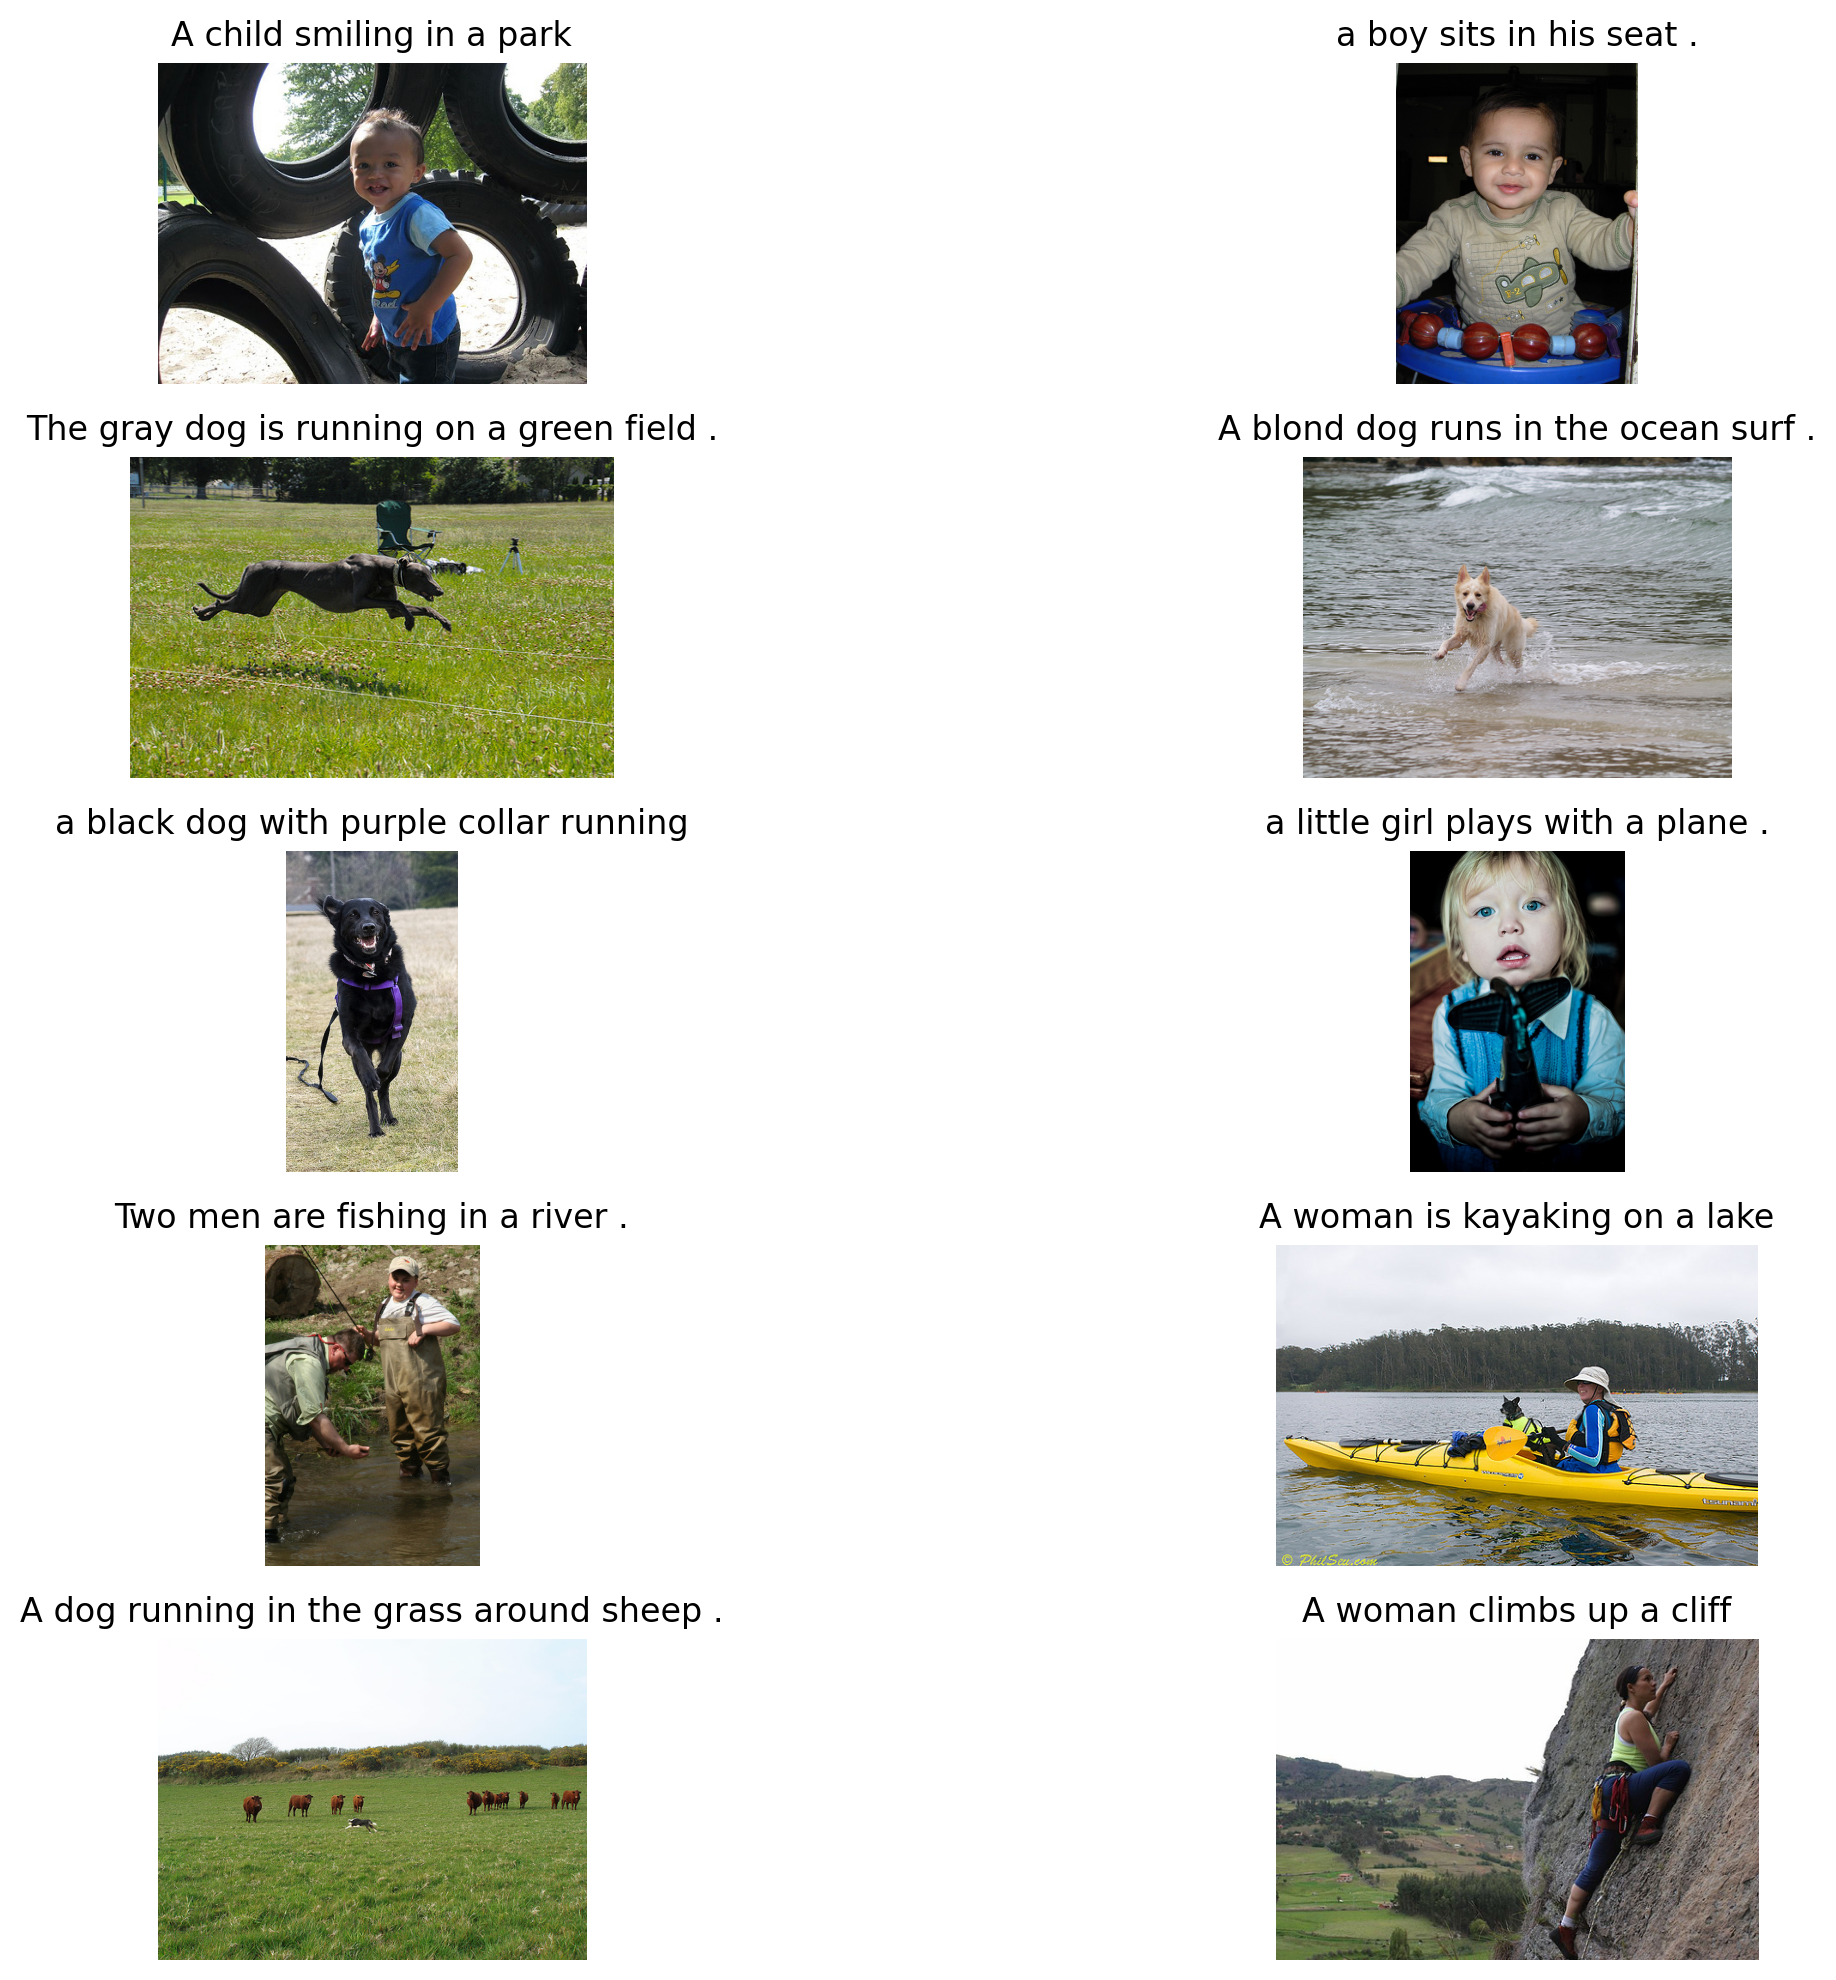

In [ ]:
imgfolder=r"files/Images"
import os
with os.scandir(imgfolder) as fb:
    files=[f.name for f in fb]
start=100
imgs=files[start:start+10]    #Selects 10 images
dfi=df[df["image"].isin(imgs)].copy()
dfi["length"]=dfi["caption"].str.len()
dfi=dfi.sort_values(['image',"length"])
dfi=dfi.groupby("image").first()    #Selects the shortest caption for each image

import PIL
from matplotlib import pyplot as plt
plt.figure(dpi=200,figsize=(15,10))
for i in range(10):
    plt.subplot(5,2, i+1)    #Plots the 10 images in five rows and two columns
    img=f"{imgfolder}/{dfi.index[i]}"
    nparray=PIL.Image.open(img)
    plt.imshow(nparray)
    plt.title(f"{dfi.iloc[i]['caption']}")    #Places the caption on top of the image
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from transformers import DistilBertTokenizer    #Imports the DistilBERT tokenizer from the transformers library

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased")
encoded=tokenizer(
    ["two dogs run",
    "an eagle flies in the sky"],
    padding=True, truncation=True,
    max_length=200)    #Generates input indexes and attention masks for a batch of two captions
print(encoded)
for indexes in encoded['input_ids']:
    tokens = tokenizer.convert_ids_to_tokens(indexes)
    print(tokens)    #Prints out the individual tokens in the two captions

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [[101, 2048, 6077, 2448, 102, 0, 0, 0], [101, 2019, 6755, 10029, 1999, 1996, 3712, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1]]}
['[CLS]', 'two', 'dogs', 'run', '[SEP]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'an', 'eagle', 'flies', 'in', 'the', 'sky', '[SEP]']


In [ ]:
import numpy as np
image_ids = np.arange(0, len(df))
np.random.seed(42) #Fixes the random state so results are reproducible
valid_ids = np.random.choice( #Uses 20% of the sample as the validation set
    image_ids, size=int(0.2 * len(df)), replace=False)
train_ids = [id_ for id_ in image_ids if id_ not in valid_ids] #The remaining 80% of the sample is the train subset.
train = df[df.index.isin(train_ids)].reset_index(drop=True)
valid = df[df.index.isin(valid_ids)].reset_index(drop=True)

In [ ]:
import torch

class CFG:
    image_path = r"files/Images"
    captions_path = r"files"
    batch_size = 32
    head_lr = 1e-3
    weight_decay = 1e-3
    patience = 1
    factor = 0.8
    epochs = 4
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = 'resnet50' #Uses the pretrained ResNet50 model to process images
    image_embedding = 2048
    text_encoder_model = "distilbert-base-uncased" #Uses the pretrained DistilBERT model to encode captions
    text_embedding = 768
    text_tokenizer = "distilbert-base-uncased"
    max_length = 200
    pretrained = True
    trainable = False
    temperature = 1.0
    size = 224 #Converts all images to a size of 3 × 224 × 224
    # for projection head; used for both image and text encoders
    num_projection_layers = 1
    projection_dim = 256 #Both text embeddings and image embeddings are 256-value vectors.
    dropout = 0.1

In [ ]:
class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self,image_filenames,captions,tokenizer,
                 transforms):
        self.image_filenames = image_filenames
        self.captions = list(captions)
        self.encoded_captions = tokenizer(
            list(captions), padding=True, truncation=True,
            max_length=CFG.max_length) #Uses the DistilBERT tokenizer to convert captions to tensors
        self.transforms = transforms
    def __getitem__(self, idx):
        item = {key: torch.tensor(values[idx])
            for key, values in self.encoded_captions.items()}
        image = cv2.imread(
            f"{CFG.image_path}/{self.image_filenames[idx]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transforms(image=image)['image']
        item['image']=torch.tensor(image).permute(2,0,1).float() #Converts raw image data to tensors
        item['caption'] = self.captions[idx]
        return item #Each item consists of an image–caption pair.
    def __len__(self):
        return len(self.captions)

In [ ]:
import albumentations as A

def get_transforms():
    return A.Compose([
            A.Resize(CFG.size, CFG.size, always_apply=True),
            A.Normalize(max_pixel_value=255.0,
                        always_apply=True),])

In [ ]:
from transformers import (DistilBertModel, DistilBertConfig,
                          DistilBertTokenizer)

tokenizer = DistilBertTokenizer.from_pretrained(
    CFG.text_tokenizer) #Instantiates the DistilBERT tokenizer
transforms = get_transforms()
trainset = CLIPDataset(train["image"].values,
    train["caption"].values,tokenizer=tokenizer,
                       transforms=transforms)
trainloader = torch.utils.data.DataLoader(trainset,
    batch_size=CFG.batch_size,shuffle=True) #Applies the CLIPDataset class on the train subset and creates a data loader
valset = CLIPDataset(valid["image"].values,
    valid["caption"].values,tokenizer=tokenizer,
                     transforms=transforms)
valloader = torch.utils.data.DataLoader(valset,
    batch_size=CFG.batch_size,shuffle=False) #Applies the CLIPDataset class on the validation subset and creates a data loader

/tmp/ipykernel_5985/2949225460.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(CFG.size, CFG.size, always_apply=True),
/tmp/ipykernel_5985/2949225460.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(max_pixel_value=255.0,


In [ ]:
import cv2

batch0=next(iter(trainloader))
print(batch0.keys())

dict_keys(['input_ids', 'attention_mask', 'image', 'caption'])


In [ ]:
print(batch0['input_ids'][0])
print(batch0['attention_mask'][0])
print(batch0['image'][0].shape)
print(batch0['caption'][0])

tensor([  101,  1037,  2158,  8521,  1037,  3586,  4147,  1037,  2630, 18019,
         8768,  1012,   102,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
torch.Size([3, 224, 224])
A man feeding a horse wearing a blue strapped blanket .


In [ ]:
from torch import nn

class TextEncoder(nn.Module):
    def __init__(self, model_name=CFG.text_encoder_model,
                 pretrained=CFG.pretrained,
                 trainable=CFG.trainable):
        super().__init__()
        if pretrained:
            self.model=DistilBertModel.from_pretrained(model_name)
        else:
            self.model=DistilBertModel(config=DistilBertConfig())
        for p in self.model.parameters():
            p.requires_grad = trainable
        self.target_token_idx = 0 #Focuses only on the first token in the caption (the starting token CLS)
    def forward(self, input_ids, attention_mask):
        output = self.model(input_ids=input_ids,
                attention_mask=attention_mask)
        last_hidden_state = output.last_hidden_state #Uses the last layer of the pretrained DistilBERT model
        return last_hidden_state[:,self.target_token_idx,:] #The text embedding is the output associated with the CLS token in the last layer.

In [ ]:
textencoder=TextEncoder()
num_trainable = sum([p.numel() for p in
    textencoder.parameters() if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in
    textencoder.parameters() if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of trainable parameters: 0
Number of untrainable parameters: 66362880


In [ ]:
encoded_text=textencoder(batch0['input_ids'],
                         batch0['attention_mask'])
print(encoded_text.shape)

torch.Size([32, 768])


In [ ]:
import timm

class ImageEncoder(nn.Module):
    def __init__(self, model_name=CFG.model_name, #Uses ResNet50 as the image encoder
                 pretrained=CFG.pretrained, #Uses the pretrained model instead of training from scratch
                 trainable=CFG.trainable): #Sets the trainable argument to False
        super().__init__()
        self.model = timm.create_model(model_name, pretrained,
            num_classes=0,global_pool="avg")
        for p in self.model.parameters():
            p.requires_grad = trainable
    def forward(self, x):
        return self.model(x)

In [ ]:
imageencoder=ImageEncoder()
num_trainable = sum([p.numel() for p in imageencoder.parameters()
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in imageencoder.parameters()
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Number of trainable parameters: 0
Number of untrainable parameters: 23508032


In [ ]:
encoded_image=imageencoder(batch0['image'])
print(encoded_image.shape)

torch.Size([32, 2048])


In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self,embedding_dim, #The dimension of the input (768 for text and 2,048 for image)
        projection_dim=CFG.projection_dim, #The dimension of the output (256 for both text and image)
        dropout=CFG.dropout):
        super().__init__()
        self.projection = nn.Linear(embedding_dim,
                                    projection_dim)
        self.gelu = nn.GELU()
        self.fc = nn.Linear(projection_dim, projection_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(projection_dim)
    def forward(self, x):
        projected = self.projection(x)
        x = self.gelu(projected)
        x = self.fc(x)
        x = self.dropout(x)
        x = x + projected
        x = self.layer_norm(x) #The input goes through the two linear layers, GELU activation, and a dropout layer, with residual connection and layer normalization.
        return x

In [ ]:
def cross_entropy(preds, targets, reduction='none'):
    log_softmax = nn.LogSoftmax(dim=-1)
    loss = (-targets * log_softmax(preds)).sum(1)
    if reduction == "none":
        return loss
    elif reduction == "mean":
        return loss.mean()

In [ ]:
import torch.nn.functional as F

class CLIPModel(nn.Module):
    def __init__(self,temperature=CFG.temperature,
        image_embedding=CFG.image_embedding,
        text_embedding=CFG.text_embedding):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_encoder = TextEncoder()
        self.image_projection = ProjectionHead(
            embedding_dim=image_embedding)
        self.text_projection = ProjectionHead(
            embedding_dim=text_embedding)
        self.temperature = temperature
    def forward(self, batch):
        image_features = self.image_encoder(batch["image"])
        text_features = self.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        ) #Uses the image encoder and text encoder to extract features
        image_embeddings = self.image_projection(image_features)
        text_embeddings = self.text_projection(text_features) #Uses projection heads to generate image and text embeddings
        logits = \
        (text_embeddings @ image_embeddings.T) / self.temperature
        images_similarity = image_embeddings @ image_embeddings.T
        texts_similarity = text_embeddings @ text_embeddings.T
        targets = F.softmax(
        (images_similarity +
         texts_similarity) / 2 * self.temperature,
        dim=-1)
        texts_loss = cross_entropy(logits, targets,
                                   reduction='none')
        images_loss = cross_entropy(logits.T, targets.T,
                                    reduction='none')
        loss =  (images_loss + texts_loss) / 2.0 #Calculates the loss to maximize the similarity between image and text embeddings
        return loss.mean()

In [ ]:
model = CLIPModel().to(CFG.device) #Instantiates the CLIPModel to create our CLIP model
num_trainable = sum([p.numel() for p in model.parameters()
                     if p.requires_grad])
print(f"Number of trainable parameters: {num_trainable}")
non_trainable = sum([p.numel() for p in model.parameters()
                     if not p.requires_grad])
print(f"Number of untrainable parameters: {non_trainable}") #Prints out the number of trainable and untrainable parameters

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of trainable parameters: 854016
Number of untrainable parameters: 89870912


In [ ]:
import itertools

params = [
    {"params": itertools.chain(
        model.image_projection.parameters(),
        model.text_projection.parameters()
    ), "lr": CFG.head_lr, "weight_decay": CFG.weight_decay}
]
optimizer = torch.optim.AdamW(params, weight_decay=0.)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=CFG.patience,
    factor=CFG.factor
)

In [ ]:
def evaluate():
    global best_loss
    model.eval()
    losses = []
    with torch.no_grad():
        tqdm_object = tqdm(valloader, total=len(valloader))
        for batch in tqdm_object:    #Iterates through all batches in the validation set
            batch = {k: v.to(CFG.device) for k, v in
                     batch.items() if k != "caption"}
            loss = model(batch)
            losses.append(loss.item())
            avgloss=sum(losses)/len(losses)    #Calculates the average loss in the epoch
            tqdm_object.set_description(
                f"valid_loss={avgloss:.2f}")
    if avgloss < best_loss:
        best_loss = avgloss
        torch.save(model.state_dict(), "files/best.pth")    #If the performance of the model is the best among all epochs, saves the model parameters
        print("Saved Best Model!")

In [ ]:
sd=torch.load(r"files/best.pth")
model.load_state_dict(sd)
model.eval()

CLIPModel(
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act2): ReLU(inplace=True)
          (aa): Identity()
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1

In [ ]:
from tqdm import tqdm

image_embeds = []
with torch.no_grad():
    for batch in tqdm(valloader):
        image_features = model.image_encoder(
            batch["image"].to(CFG.device))
        image_embeds.append(
            model.image_projection(image_features))
image_embeddings = torch.cat(image_embeds)

100%|██████████| 253/253 [00:44<00:00,  5.65it/s]


In [ ]:
import pickle

with open("files/image_embeds.p","wb") as f:
    pickle.dump(image_embeddings, f)

In [ ]:
def match(prompt):
    encoded = tokenizer([prompt])    #Tokenizes the prompt
    batch = {
        key: torch.tensor(values).to(CFG.device)
        for key, values in encoded.items()
    }
    with torch.no_grad():
        text_features = model.text_encoder(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )
        text_embeddings = model.text_projection(
        text_features)    #Creates a text embedding
    dot_similarity = text_embeddings @ image_embeddings.T
    values, idx = torch.topk(dot_similarity.squeeze(0), 1)    #Selects the image with the highest value of similarity with the text prompt
    img=valid['image'].values[idx.item()]
    caption=valid['caption'].values[idx.item()]
    return img, caption

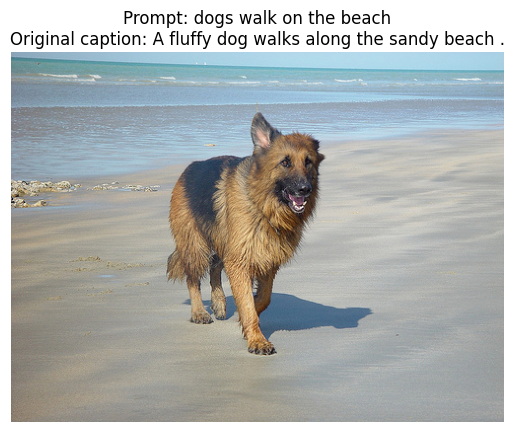

In [ ]:
prompt="dogs walk on the beach"#aici--------------------------------------------------------------------------------------------------
file,cap=match(prompt) #Finds a match for the prompt
plt.imshow(PIL.Image.open(
    rf"files/Images/{file}"))
plt.title(f"Prompt: {prompt}\nOriginal caption: {cap}") #Displays the selected image, the prompt, and the original caption
plt.axis("off")
plt.show()

2. Use the find_match() function to select an image from the Flickr 8k dataset based on the text prompt “people shopping on the street”. Plot the selected images in a  1×5  grid.

In [ ]:
!git clone https://github.com/openai/CLIP

Cloning into 'CLIP'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 265 (delta 1), reused 0 (delta 0), pack-reused 260 (from 2)
Receiving objects: 100% (265/265), 8.87 MiB | 34.29 MiB/s, done.
Resolving deltas: 100% (137/137), done.


In [ ]:
import sys

sys.path.append("./CLIP")

#Urmatoarea celula a fost modificata de catre gemini deoarece crapa codul incercand sa loaduie si prprocess toate imaginile intr un singur tensor

In [ ]:
import os
import torch
import clip
from PIL import Image
from tqdm.auto import tqdm # Import tqdm for progress bar

folder=r"files/Images"
with os.scandir(folder) as files:
    names=[file.name for file in files]

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)    #Loads the pretrained OpenAI CLIP model

image_features_list = []
batch_size_clip = 64  # Define a suitable batch size

# Process images in batches to avoid OutOfMemoryError
for i in tqdm(range(0, len(names), batch_size_clip), desc="Encoding images"):
    batch_names = names[i:i + batch_size_clip]
    batch_images = []
    for name in batch_names:
        img_path = f"{folder}/{name}"
        # Ensure image is in RGB format
        image_pil = Image.open(img_path).convert("RGB")
        batch_images.append(preprocess(image_pil))

    # Stack preprocessed images into a batch tensor and move to device
    batch_tensor = torch.stack(batch_images).to(device)

    with torch.no_grad():
        batch_features = model.encode_image(batch_tensor)
        image_features_list.append(batch_features)

image_features = torch.cat(image_features_list) # Concatenate all batch features

print(image_features.shape)
with open("files/imgfeas.p","wb") as fb:
    pickle.dump(image_features.cpu(), fb)    # Saves the image embeddings to CPU to avoid device issues upon loading

Encoding images:   0%|          | 0/127 [00:00<?, ?it/s]

torch.Size([8091, 512])


In [ ]:
import PIL
from matplotlib import pyplot as plt

def find_match(prompt):
    print(f"prompt is {prompt}")
    text = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        text_features = model.encode_text(text) #Encodes the text prompt into a text embedding
    simu=text_features@image_features.T #Calculates the similarities between the text and all images
    values, indices = torch.topk(simu[0], 5) #Selects the best-matched five images based on the similarities
    plots=[]
    for i in indices:
        plots.append(names[i])
    plt.figure(dpi=200,figsize=(10,2))
    for i in range(5): #Plots the five images in a 1 × 5 grid
        plt.subplot(1,5, i+1)
        img=f"{folder}/{plots[i]}"
        nparray=PIL.Image.open(img)
        plt.imshow(nparray)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

prompt is people eating at the restaurant


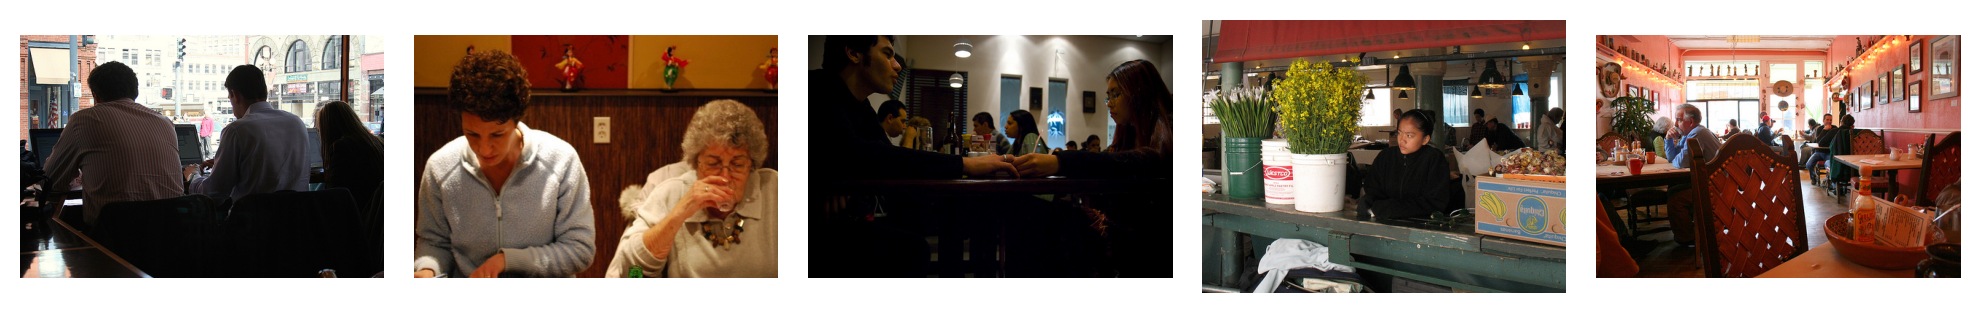

In [ ]:
import pickle

with open("files/imgfeas.p","rb") as fb:
    image_features=pickle.load(fb).to(device) # Move image_features to the GPU------------------------------------------------------------
find_match("people eating at the restaurant")